In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.ticker as ticker
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
import os

data_dir = "/home/ymascolo/Desktop/github/datasets" # path datsets



## Diagrams plot

In [2]:
# =============================================================
# FUNCTIONS
# =============================================================

def get_planet_params(df, identifier, by='pl_name'):
    """
    Extracts planetary parameters (Mass, Radius, and Equilibrium Temperature) 
    along with their uncertainties from a NASA Exoplanet Archive DataFrame.

    Parameters:
    -----------
    df : pandas.DataFrame
        The dataset containing planet properties.
    identifier : str or None
        The value to filter by (e.g., specific planet name). If None, returns the whole dataset.
    by : str, default 'pl_name'
        The column name used to filter the dataframe.

    Returns:
    --------
    dict
        A dictionary containing:
        - 'M': Planet mass(es) [Earth masses]
        - 'Merr': Asymmetric lower and upper mass errors
        - 'R': Planet radius/radii [Earth radii]
        - 'Rerr': Asymmetric lower and upper radius errors
        - 'Teq': Equilibrium temperature(s) [K]
    """
    # Filter the dataframe if a specific identifier is provided
    if identifier is not None:
        planet = df[df[by] == identifier].copy()
    else:
        planet = df.copy()

    # Case 1: Single planet found: Extract as scalar values
    if len(planet) == 1:
        planet = planet.iloc[0]

        M = planet["pl_bmasse"]
        Merr = [abs(planet["pl_bmasseerr2"]), planet["pl_bmasseerr1"]]

        R = planet["pl_rade"]
        Rerr = [abs(planet["pl_radeerr2"]), planet["pl_radeerr1"]]

        Teq = planet["pl_eqt"]

    # Case 2: Multiple planets or whole dataset: Extract as NumPy arrays
    else:
        M = planet["pl_bmasse"].values
        Merr = [np.abs(planet["pl_bmasseerr2"].values), planet["pl_bmasseerr1"].values]

        R = planet["pl_rade"].values
        Rerr = [np.abs(planet["pl_radeerr2"].values), planet["pl_radeerr1"].values]

        Teq = planet["pl_eqt"].values

    return {'M': M, 'Merr': Merr, 'R': R, 'Rerr': Rerr, 'Teq': Teq}


# -----------------------------
# MASS-RADIUS planet plot
# -----------------------------
def plot_planet_MR(ax, M, R, Merr, Rerr, Teq, label, vmin, vmax, dx=0.25, dy=0.03, color='k', s=30):
    """
    Plots a single planet on a Mass-Radius diagram, color-coded by its equilibrium temperature.

    Parameters:
    -----------
    ax : matplotlib.axes.Axes
        The axes object where the planet will be plotted.
    M, R, Teq : float or array-like
        Mass, Radius, and Equilibrium Temperature of the planet.
    Merr, Rerr : list or array-like
        Asymmetric error bars for Mass and Radius.
    label : str
        The text label/name of the planet.
    vmin, vmax : float
        Min/Max limits for the temperature colormap.
    dx, dy : float, default dx=0.25, dy=0.03
        Offsets for positioning the text label relative to the data point.
    color : str, default 'k'
        Color of the error bars and text label.
    s : int, default 30
        Marker size.
    """
    # Ensure inputs are treated as standard floats
    M = float(np.squeeze(M))
    R = float(np.squeeze(R))
    Teq = float(np.squeeze(Teq))

    # Helper function to format errors for matplotlib's errorbar (requires shape 2x1)
    def format_err(err):
        if np.isscalar(err):
            return [[err], [err]]
        err = np.squeeze(err)
        return [[float(err[0])], [float(err[1])]]

    # Scatter plot color-coded by Equilibrium Temperature (Teq) using the Purples colormap
    ax.scatter(M, R, c=Teq, cmap="Purples", vmin=vmin, vmax=vmax,
               s=s, edgecolor='k', zorder=5)

    # Plot asymmetric error bars
    ax.errorbar(M, R,
                xerr=format_err(Merr),
                yerr=format_err(Rerr),
                fmt='none', color=color, alpha=0.9, zorder=4)

    # Add text annotation for the planet label
    ax.annotate(label, (M + dx, R + dy), fontsize=10,  color=color)


# -----------------------------
# ZENG MODEL
# -----------------------------
def build_zeng_rocky_interpolator(file):
    """
    Loads interior model data from Zeng et al. 2019 and builds a 1D interpolator 
    to estimate a purely rocky planet's bulk density as a function of its mass.

    Parameters:
    -----------
    file : str
        Path to the text file containing the Zeng Earth-like model data (Columns: Mass, Radius).

    Returns:
    --------
    scipy.interpolate.interp1d
        An interpolator object that outputs normalized density given a specific Mass.
    """
    # Load model data: Expected Column 0 = Mass, Column 1 = Radius
    data = np.loadtxt(file)
    M = data[:, 0]
    R = data[:, 1]

    # Sort data by Mass to ensure proper interpolation
    idx = np.argsort(M)
    M = M[idx]
    R = R[idx]

    # Calculate density proxy (rho ~ M / R^3)
    rho = M / R**3

    # Return the 1D interpolator with extrapolation enabled
    return interp1d(M, rho, bounds_error=False, fill_value="extrapolate")


def rho_normalized(M, R, f_rho_rocky):
    """
    Calculates the normalized bulk density of a planet relative to a reference 
    rocky interior model (Zeng model) for the same mass.

    Parameters:
    -----------
    M : float or array-like
        Planet Mass.
    R : float or array-like
        Planet Radius.
    f_rho_rocky : callable
        Interpolator function (e.g., from build_zeng_rocky_interpolator).

    Returns:
    --------
    float or array-like
        The normalized density. A value around 1 indicates an Earth-like rocky composition.
    """
    return (np.asarray(M) / np.asarray(R)**3) / f_rho_rocky(M)


# -----------------------------
# MASS-DENSITY planet plot
# -----------------------------
def plot_planet_rho(ax, M, R, Merr, Rerr, Teq, label, f_rho_rocky,
                    vmin, vmax, dx=0.2, dy=0.02, color='k', s=30):
    """
    Plots a single planet on a Mass vs. Normalized Density diagram, 
    properly propagating errors from Mass and Radius into the density domain.

    Parameters:
    -----------
    ax : matplotlib.axes.Axes
        The axes object where the planet will be plotted.
    M, R, Teq : float or array-like
        Mass, Radius, and Equilibrium Temperature of the planet.
    Merr, Rerr : list or array-like
        Asymmetric error bars for Mass and Radius.
    label : str
        The text label/name of the planet.
    f_rho_rocky : callable
        Interpolator function for the reference rocky composition.
    vmin, vmax : float
        Min/Max limits for the temperature colormap.
    dx, dy : float, default dx=0.2, dy=0.02
        Offsets for positioning the text label.
    color : str, default 'k'
        Color of the error bars and text label.
    s : int, default 30
        Marker size.
    """
    M = float(np.squeeze(M))
    R = float(np.squeeze(R))
    Teq = float(np.squeeze(Teq))

    rho = rho_normalized(M, R, f_rho_rocky)

    # Helper function to unpack asymmetric errors
    def get_err(err):
        if np.isscalar(err):
            return err, err
        err = np.squeeze(err)
        return float(err[0]), float(err[1])

    Mlow, Mhigh = get_err(Merr)
    Rlow, Rhigh = get_err(Rerr)

    # Propagate errors: 
    rho_low = rho_normalized(M - Mlow, R + Rhigh, f_rho_rocky)
    rho_high = rho_normalized(M + Mhigh, R - Rlow, f_rho_rocky)
    yerr = [[rho - rho_low], [rho_high - rho]]

    ax.scatter(M, rho, c=Teq, cmap="Purples",
               vmin=vmin, vmax=vmax, edgecolor='k', zorder=5, s=s)

    ax.errorbar(M, rho,
                xerr=[[Mlow], [Mhigh]],
                yerr=yerr,
                fmt='none', color=color, alpha=0.9, zorder=4)

    ax.text(M + dx, rho + dy, label, fontsize=10,  color=color)

# =============================
# CONVERT CURVES TO RHO NORM
# =============================

def convert_curve_to_rho_norm(curve, f_rho_rocky):
    """
    Converts a theoretical composition curve from the Mass-Radius space into the Mass-Normalized Density space.

    Parameters:
    -----------
    curve : numpy.ndarray
        A 2D array where curve[:, 0] is Mass and curve[:, 1] is Radius.
    f_rho_rocky : callable
        Interpolator function for the reference rocky composition.

    Returns:
    --------
    tuple
        (Mass array, Normalized Density array)
    """
    M = curve[:, 0]
    R = curve[:, 1]
    rho_norm = rho_normalized(M, R, f_rho_rocky)
    return M, rho_norm


# -----------------------------
# Habitable zone planets
# -----------------------------
def plot_planet_HZ(ax, Mstar, P, Teq, label, vmin, vmax, dx=0.25, dy=0.03, edgecolor='k', s=30, color='k'):
    """
    Plots a planet on a Stellar Mass vs. Orbital Period diagram, for analyzing planets in the Habitable Zone.

    Parameters:
    -----------
    ax : matplotlib.axes.Axes
        The axes object where the planet will be plotted.
    Mstar : float or array-like
        Mass of the host star [Solar masses].
    P : float or array-like
        Orbital period of the planet [days].
    Teq : float or array-like
        Equilibrium Temperature of the planet [K].
    label : str
        The text label/name of the planet.
    vmin, vmax : float
        Min/Max limits for the temperature colormap.
    dx, dy : float, default dx=0.25, dy=0.03
        Offsets for positioning the text label.
    edgecolor : str, default 'k'
        Color of the marker border.
    s : int, default 30
        Marker size.
    color : str, default 'k'
        Color of the text label.
    """
    Mstar = float(np.squeeze(Mstar))
    P = float(np.squeeze(P))
    Teq = float(np.squeeze(Teq))

    # Scatter plot mapping Stellar Mass vs. Planet Orbital Period
    ax.scatter(Mstar, P, c=Teq, cmap="Purples", vmin=vmin, vmax=vmax,
               s=s, edgecolor=edgecolor, zorder=5)

    # Add text annotation
    ax.annotate(label, (Mstar + dx, P + dy), fontsize=10, color=color)

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


Snow line for LHS 6050: 0.211 AU


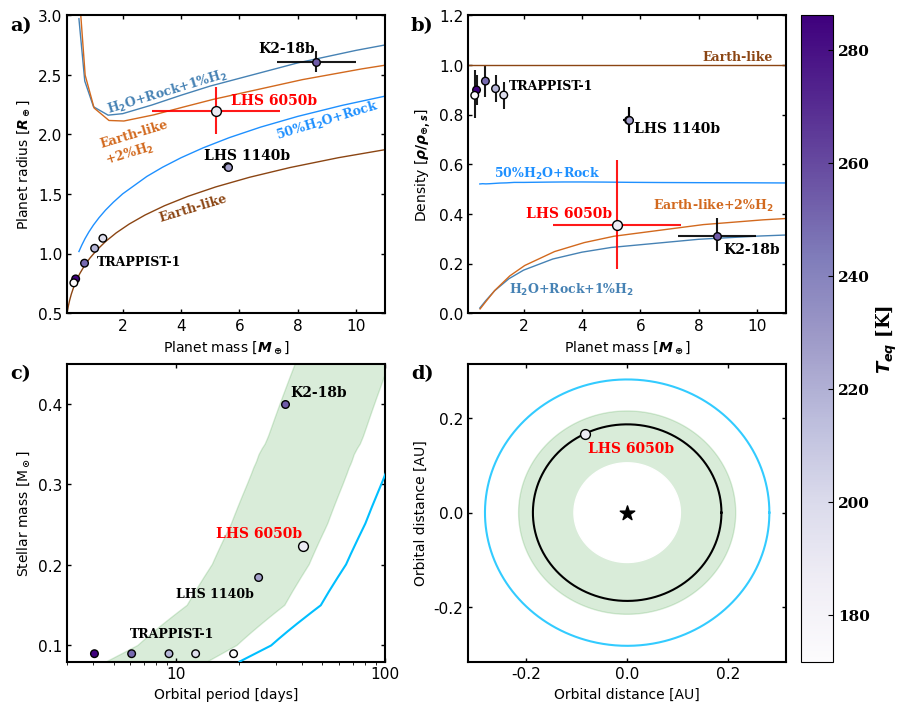

In [3]:
# =============================================================
# DATA FILTER
# =============================================================

# from Nasa Exoplanets Archive
df_confirmed = pd.read_csv(os.path.join(data_dir,"PSCompPars_2026.03.18_18.12.35.csv"), comment='#')

df = df_confirmed[
    (df_confirmed["pl_bmasse"] < 11) &
    (df_confirmed["pl_bmasse"] >= 0.1) &
    (df_confirmed["pl_rade"] <= 3.5) &
    (df_confirmed["pl_eqt"] <= 300) &
    (df_confirmed["pl_bmasseerr1"].notna()) &
    (df_confirmed["pl_bmasseerr2"].notna()) &
    (df_confirmed["pl_radeerr1"].notna()) &
    (df_confirmed["pl_radeerr2"].notna()) &
    (df_confirmed["pl_bmasseerr1"] <= 1.5) &
    (df_confirmed["pl_orbper"] <= 100) &
    (df_confirmed["pl_orbpererr1"].notna()) &
    (df_confirmed["pl_orbpererr2"].notna()) &
    (df_confirmed["pl_name"] != "K2-18 b") # remove because we used more updated values
]

all_planets = get_planet_params(df, None)
lhs1140b = get_planet_params(df, "LHS 1140 b")

# parameters LHS 6050 system
mass_our_planet = 5.2
err_mass_our_planet = 2.2
rad_our_planet = 2.2
err_rad_our_planet = 0.2
temp_our_planet = 188

# =============================================================
# MODEL
# =============================================================

f_rho_rocky = build_zeng_rocky_interpolator(
    os.path.join(data_dir,"zeng_curves/EarthlikeRocky.txt"))     

# =============================
# LOAD MODEL CURVES
# =============================

h2050 = np.loadtxt(os.path.join(data_dir,"zeng_curves/50H2O_300K_1mbar.txt"))
h2 = np.loadtxt(os.path.join(data_dir,"zeng_curves/50H2O_1H_300K_1mbar.txt"))
fe33 = np.loadtxt(os.path.join(data_dir,"zeng_curves/EarthlikeRocky.txt"))
earthlike_1h = np.loadtxt(os.path.join(data_dir,"zeng_curves/Earthlike_2H_300K_1mbar.txt"))

# =============================================================
# PREPARE DATA
# =============================================================

vmin = all_planets['Teq'].min()
vmax = all_planets['Teq'].max()

all_rho = rho_normalized(all_planets['M'], all_planets['R'], f_rho_rocky)

M_arr = np.array(all_planets['M'])
R_arr = np.array(all_planets['R'])

Mlow = np.array(all_planets['Merr'][0])
Mhigh = np.array(all_planets['Merr'][1])

Rlow = np.array(all_planets['Rerr'][0])
Rhigh = np.array(all_planets['Rerr'][1])

rho = rho_normalized(M_arr, R_arr, f_rho_rocky)
rho_low = rho_normalized(M_arr - Mlow, R_arr + Rhigh, f_rho_rocky)
rho_high = rho_normalized(M_arr + Mhigh, R_arr - Rlow, f_rho_rocky)

yerr = [rho - rho_low, rho_high - rho]

# =============================================================
# FIGURE
# =============================================================

fig, ax = plt.subplots(2, 2, figsize=(9, 7), sharex=False, constrained_layout = True)

plt.rcParams.update({
    "font.size": 13,
    "font.family": "serif",
    'font.weight': 'bold',        # Bold standard text
    'axes.labelweight': 'bold',   # Bold X and Y labels
    'axes.titleweight': 'bold',   # Bold Title
    'figure.titleweight': 'bold',  # Bold Figure title
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    'mathtext.fontset': 'custom',
    'mathtext.bf': 'sans:bold',
    'mathtext.rm': 'sans',
})


# ------------------ MASS-RADIUS ------------------

sc = ax[0,0].scatter(all_planets['M'], all_planets['R'],
                 c=all_planets['Teq'], cmap="Purples",
                 vmin=vmin, vmax=vmax,
                 s=30, edgecolor='k', zorder=5)

ax[0,0].errorbar(all_planets['M'], all_planets['R'],
             xerr=all_planets['Merr'],
             yerr=all_planets['Rerr'],
             fmt='none', color='k', alpha=0.9)

plot_planet_MR(ax[0,0], 8.63, 2.61, 1.35, 0.087, 254, "K2-18b", vmin, vmax, dy=0.08, dx=-2.)
plot_planet_MR(ax[0,0], mass_our_planet, rad_our_planet, err_mass_our_planet, err_rad_our_planet, temp_our_planet, "LHS 6050b", vmin, vmax, color='r', dx=0.5, dy=+0.05,  s=50)
plot_planet_MR(ax[0,0], lhs1140b['M'], lhs1140b['R'],
               lhs1140b['Merr'], lhs1140b['Rerr'],
               lhs1140b['Teq'], "LHS 1140b", vmin, vmax, dx=-0.8, dy=0.06)
ax[0,0].text(1.1, 0.9, 'TRAPPIST-1', color='k', fontsize=9)
ax[0,0].text(-0.18, 0.95, 'a)', fontsize=14, transform=ax[0,0].transAxes)

# MODEL CURVES - MASS-RADIUS
ax[0,0].plot(h2050[:,0], h2050[:,1], color="dodgerblue", lw=1)
ax[0,0].plot(h2[:,0], h2[:,1], color="steelblue", lw=1)
ax[0,0].plot(fe33[:,0], fe33[:,1], color="saddlebrown", lw=1)
ax[0,0].plot(earthlike_1h[:,0], earthlike_1h[:,1], color="chocolate", lw=1)

i = 5
dx = h2050[i+1,0] - h2050[i-1,0]
dy = h2050[i+1,1] - h2050[i-1,1]
angle = np.degrees(np.arctan2(dy, dx))

ax[0,0].text(h2050[i,0]+6., h2050[i,1]+0.66, "50%H$_2$O+Rock", color='dodgerblue', fontsize=9, rotation=angle)
ax[0,0].text(h2050[i,0]+2., h2050[i,1]-0.03, "Earth-like", color='saddlebrown', fontsize=9, rotation=angle)
ax[0,0].text(h2050[i,0], h2050[i,1]+0.45, "Earth-like\n+2%H$_2$", color='chocolate', fontsize=9, rotation=angle)
ax[0,0].text(h2050[i,0]+0.2, h2050[i,1]+0.88, "H$_2$O+Rock+1%H$_2$", color='steelblue', fontsize=9, rotation=angle)

ax[0,0].set_ylabel("Planet radius [$R_\\oplus$]")
ax[0,0].set_xlabel("Planet mass [$M_\\oplus$]")
ax[0,0].set_ylim(0.5, 3)
ax[0,0].set_xlim(0.1, 11)

for side in ['top', 'bottom', 'left', 'right']:
    ax[0,0].spines[side].set_linewidth(1.5)
    ax[0,0].spines[side].set_edgecolor('black')
ax[0,0].grid(False)
ax[0,0].set_facecolor('white')
ax[0,0].tick_params(axis='both', which='major', labelsize=11,
               width=1, length=3, color='black', direction='in', top=True, right=True)



# ------------------ MASS-DENSITY ------------------

M_h2, rho_h2 = convert_curve_to_rho_norm(h2, f_rho_rocky)
M_h2050, rho_h2050 = convert_curve_to_rho_norm(h2050, f_rho_rocky)
M_fe33, rho_fe33 = convert_curve_to_rho_norm(fe33, f_rho_rocky)
M_earthlike_1h, rho_earthlike_1h = convert_curve_to_rho_norm(earthlike_1h, f_rho_rocky)

sc2 = ax[0,1].scatter(M_arr, rho,
                  c=all_planets['Teq'],
                  cmap="Purples",
                  vmin=vmin, vmax=vmax,
                  s=30, edgecolor='k', zorder=5)

ax[0,1].errorbar(M_arr, rho,
             xerr=[Mlow, Mhigh],
             yerr=yerr,
             fmt='none', color='k', alpha=0.9)

plot_planet_rho(ax[0,1], 8.63, 2.61, 1.35, 0.087, 254, "K2-18b", f_rho_rocky, vmin, vmax, dy=-0.07)
plot_planet_rho(ax[0,1],mass_our_planet, rad_our_planet, err_mass_our_planet, err_rad_our_planet, temp_our_planet, "LHS 6050b", f_rho_rocky, vmin, vmax, color='r', dx=-3.1, dy=0.03,s=50)
plot_planet_rho(ax[0,1], lhs1140b['M'], lhs1140b['R'],
                lhs1140b['Merr'], lhs1140b['Rerr'],
                lhs1140b['Teq'], "LHS 1140b", f_rho_rocky, vmin, vmax, dy=-0.05)

# MODEL CURVES - MASS-DENSITY
ax[0,1].plot(M_h2, rho_h2, color="steelblue", lw=1)
ax[0,1].plot(M_h2050, rho_h2050, color="dodgerblue", lw=1)
ax[0,1].plot(M_fe33, rho_fe33, color="saddlebrown", lw=1)
ax[0,1].plot(M_earthlike_1h, rho_earthlike_1h, color="chocolate", lw=1)

ax[0,1].text(M_h2[10]-10.5, rho_h2[10]-0.24, "H$_2$O+Rock+1%H$_2$", color='steelblue', fontsize=9)
ax[0,1].text(M_h2050[8]-1, rho_h2050[8]+0.02, "50%H$_2$O+Rock", color='dodgerblue', fontsize=9)
ax[0,1].text(M_fe33[20]+7, rho_fe33[20]+0.02, "Earth-like", color='saddlebrown', fontsize=9)
ax[0,1].text(M_earthlike_1h[10]-5.8, rho_earthlike_1h[10]+0.03, "Earth-like+2%H$_2$", color='chocolate', fontsize=9)
ax[0,1].text(1.5, 0.9, 'TRAPPIST-1', color='k', fontsize=9)

ax[0,1].set_xlabel("Planet mass [$M_\\oplus$]")
ax[0,1].set_ylabel("Density [$\\rho / \\rho_{\\oplus,s}$]")
ax[0,1].set_ylim(0, 1.2)
ax[0,1].set_xlim(0.1, 11)

for side in ['top', 'bottom', 'left', 'right']:
    ax[0,1].spines[side].set_linewidth(1.5)
    ax[0,1].spines[side].set_edgecolor('black')
ax[0,1].grid(False)
ax[0,1].set_facecolor('white')
ax[0,1].tick_params(axis='both', which='major', labelsize=11,
               width=1, length=3, color='black', direction='in', top=True, right=True)
ax[0,1].text(-0.18, 0.95, 'b)', fontsize=14, transform=ax[0,1].transAxes)


# ------------------ SEMI-MAJOR AXIS vs INCIDENT FLUX ----------------

M_star_pl = df["st_mass"].values  
P_pl = df["pl_orbper"].values 
Teq = df["pl_eqt"].values


def HZ(S_sun, a,b,c,d, Teff, L, M_star):
    Teff = np.array(Teff)
    L = np.array(L)
    T_star = Teff - 5780
    S = S_sun + a*T_star + b*(T_star**2) + c*(T_star**3) + d*(T_star**4)
    dist = (L/S)**0.5
    P = 365.25 * np.sqrt(dist**3 / M_star)
    return dist, S, P

# import isochrones for M-dwarfs
mist = pd.read_csv(os.path.join(data_dir,"zeng_curves/isoc.iso"),delim_whitespace=True)
Mstar_mist = mist['initial_mass'][:200]
Rstar_mist = 10**mist['log_R'][:200]
Teff_mist = 10**mist['log_Teff'][:200]
L_mist = 10**mist['log_L'][:200]

Mstar = np.insert(mist['initial_mass'][:200], 0, 0.08)
Rstar = np.insert(10**mist['log_R'][:200], 0, 0.1)
Teff  = np.insert(10**mist['log_Teff'][:200], 0, 2566)
L     = np.insert(10**mist['log_L'][:200], 0, 0.00054)

S_sun_inner = 1.188
a_inner, b_inner, c_inner, d_inner = 1.433e-4, 1.707e-8, -8.968e-12, -2.084e-15
dist_inner, S_inner, P_inner = HZ(S_sun_inner, a_inner, b_inner, c_inner, d_inner, Teff, L, Mstar)

S_sun_outer = 0.356
a_outer, b_outer, c_outer, d_outer = 6.171e-5, 1.698e-9, -3.198e-12, -5.575e-16
dist_outer, S_outer, P_outer = HZ(S_sun_outer, a_outer, b_outer, c_outer, d_outer, Teff, L, Mstar)

# M Dwarf Water Snow Line
# We assume the snow line is where the equilibrium temperature is ~170K
S_snow = (170 / 278.3)**4 
dist_snow_mdwarf = np.sqrt(L / S_snow)
# Convert distance to Orbital Period
P_snow_mdwarf = 365.25 * np.sqrt(dist_snow_mdwarf**3 / Mstar)

ax[1,0].plot(P_snow_mdwarf, Mstar, color="deepskyblue", linestyle="-", lw=1.5, zorder=3)

ax[1,0].fill_betweenx(
    Mstar, 
    P_inner, 
    P_outer, 
    color="green", alpha=0.15)

sc3 = ax[1,0].scatter(P_pl, M_star_pl, c=Teq, cmap="Purples", vmin=vmin, vmax=vmax, s=30, edgecolor='k', zorder=5)

plot_planet_HZ(ax[1,0], 33, 0.4, 254, 'K2-18b', vmin, vmax, dx=2, dy=0.01)
plot_planet_HZ(ax[1,0], 40.38, 0.224, temp_our_planet, 'LHS 6050b', vmin, vmax, dy=0.01, dx=-25, edgecolor='k', s=50, color='r')
ax[1,0].text(6, 0.11,  'TRAPPIST-1', color='k', fontsize=9)
ax[1,0].text(10, 0.16,  'LHS 1140b', color='k', fontsize=9)

ax[1,0].set_xlabel("Orbital period [days]")
ax[1,0].set_ylabel("Stellar mass [M$_\\odot$]")
ax[1,0].set_xlim(3, 100)
ax[1,0].set_ylim(0.08, 0.45)
ax[1,0].set_xscale('log')

for side in ['top', 'bottom', 'left', 'right']:
    ax[1,0].spines[side].set_linewidth(1.5)
    ax[1,0].spines[side].set_edgecolor('black')
ax[1,0].grid(False)
ax[1,0].set_facecolor('white')
ax[1,0].tick_params(axis='both', which='major', labelsize=11,
               width=1, length=3, color='black', direction='in', top=True, right=True)
ax[1,0].xaxis.set_major_formatter(ticker.ScalarFormatter())
ax[1,0].yaxis.set_major_locator(MaxNLocator(4))
ax[1,0].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax[1,0].text(-0.18, 0.95, 'c)', fontsize=14, transform=ax[1,0].transAxes)


# ------------------ VIEW OF SYSTEM ----------------

a = 0.14        # AU 
e = 0.        
Teff_6050 = 3220      # K 
Rstar_6050 = 0.254    # Rsun 
Mstar_6050 = 0.225    # Msun
Lstar_6050 = 0.00621  # Lsun

Rstar_au = Rstar_6050 * 0.00465047

# Snow line Using the ~170K equilibrium temperature threshold
S_snow = (170 / 278.3)**4 
r_snow = np.sqrt(Lstar_6050 / S_snow) 

print(f"Snow line for LHS 6050: {r_snow:.3f} AU")


# Kopparapu et al 2013 coefficients
# (Runaway greenhouse / Max greenhouse)
r_in, S_in, P_in = HZ(S_sun_inner, a_inner, b_inner, c_inner, d_inner, Teff_6050, Lstar_6050, Mstar_6050)
r_out, S_out, P_out = HZ(S_sun_outer, a_outer, b_outer, c_outer, d_outer, Teff_6050, Lstar_6050, Mstar_6050)

theta = np.linspace(0, 2*np.pi, 2000)
r = a * (1 - e**2) / (1 + e * np.cos(theta))

x = r * np.cos(theta) 
y = r * np.sin(theta)

# HZ circles
theta_c = np.linspace(0, 2*np.pi, 1000)

x_in = r_in * np.cos(theta_c)
y_in = r_in * np.sin(theta_c)

x_out = r_out * np.cos(theta_c)
y_out = r_out * np.sin(theta_c)

A = 0.3  # Bond albedo 
Teq_6050 = temp_our_planet 

# Create the circle coordinates
x_snow = r_snow * np.cos(theta_c)
y_snow = r_snow * np.sin(theta_c)

# -----------------------------
# Plot
# -----------------------------

ax[1,1].plot(x_snow, y_snow, color='deepskyblue', linestyle='-', lw=1.5, alpha=0.8, zorder=1)
# HZ annulus
ax[1,1].fill(x_out, y_out, color='green', alpha=0.15)
ax[1,1].fill(x_in, y_in, color='white')

# Orbit colored by flux
sc4 = ax[1,1].plot(x, y, c='k')

# Star
ax[1,1].scatter(0, 0, color='k', marker="*", s=120)

# Planet
theta0 = 90
r0 = a * (1 - e**2) / (1 + e * np.cos(theta0))
x0 = r0 * np.cos(theta0) 
y0 = r0 * np.sin(theta0)
ax[1,1].scatter(x0, y0, edgecolor='k', c=Teq_6050, cmap="Purples", vmin=vmin, vmax=vmax, marker=".", s=200, zorder=6)
ax[1,1].text(x0+0.005, y0-0.03,  'LHS 6050b', color='r', fontsize=10)
ax[1,1].set_xlabel("Orbital distance [AU]")
ax[1,1].set_ylabel("Orbital distance [AU]")

for side in ['top', 'bottom', 'left', 'right']:
    ax[1,1].spines[side].set_linewidth(1.5)
    ax[1,1].spines[side].set_edgecolor('black')
ax[1,1].grid(False)
ax[1,1].set_facecolor('white')
ax[1,1].tick_params(axis='both', which='major', labelsize=11,
               width=1, length=3, color='black', direction='in', top=True, right=True)
ax[1,1].xaxis.set_major_formatter(ticker.ScalarFormatter())
ax[1,1].xaxis.set_major_locator(MaxNLocator(4))
ax[1,1].yaxis.set_major_locator(MaxNLocator(4))
ax[1,1].xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax[1,1].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

limit = r_snow + 0.025
ax[1,1].set_ylim(-limit, limit)
ax[1,1].set_xlim(-limit, limit)

ax[1,1].text(-0.18, 0.95, 'd)', fontsize=14, transform=ax[1,1].transAxes)


# ------------------ COLORBAR ------------------
cbar = fig.colorbar(sc, ax=[ax[0,0], ax[0,1], ax[1,0], ax[1,1]], pad=0.02)
cbar.set_label("$T_{eq}$ [K]", fontsize=13)
cbar.ax.tick_params(labelsize=11)

#plt.savefig('diagrams.pdf', dpi=300)
plt.show()